## Environment and Repository Setup

Installs scientific-Python dependencies and ensures the working directory is the `finn` repo root. Runs on a clean Colab CPU runtime; on a local clone the clone step is skipped automatically.

In [ ]:
# Colab's runtime sometimes ends up with a CORRUPT numpy install — files
# like `numpy/_core/strings.py` end up from a different numpy version than
# `numpy/_core/umath.py` in the same directory. `pip install --force-reinstall`
# overlays the new files but does NOT delete leftovers, so the corruption
# survives. Symptom:
#   ImportError: cannot import name '_center' from 'numpy._core.umath'
#
# Fix: explicit uninstall of numpy/pandas/scipy BEFORE the pinned install,
# then one fresh pip install transaction for the whole scientific stack.
# Use `/tmp/finn_deps_done` as an idempotency marker so repeated cell runs
# on the same kernel don't re-download everything.
import os, sys, subprocess
from pathlib import Path

MARKER = Path("/tmp/finn_deps_done")
PINNED = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.13.1",
    "scikit-learn==1.5.2",
    "statsmodels==0.14.2",
    "yfinance>=0.2.60",
    "curl_cffi",
    "arch",              # needed for GARCH(1,1)
    "loguru", "tqdm", "pyyaml",
]
print()


if not MARKER.exists():
    print("→ Uninstalling any stale numpy/pandas/scipy (ignore 'not installed' warnings)…")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-qy", "numpy", "pandas", "scipy"],
        check=False,
    )
    print("→ Installing pinned scientific stack in a single transaction…")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + PINNED
    )
    MARKER.touch()
else:
    print("✓ Deps already installed in this runtime (skipping reinstall).")

# If numpy/pandas were imported before we reinstalled, the kernel still has
# the broken copy in memory. Force a manual restart in that case.
_stale = []
if "numpy" in sys.modules and sys.modules["numpy"].__version__ != "1.26.4":
    _stale.append(f"numpy={sys.modules['numpy'].__version__}")
if "pandas" in sys.modules and sys.modules["pandas"].__version__ != "2.2.2":
    _stale.append(f"pandas={sys.modules['pandas'].__version__}")
if _stale:
    raise SystemExit(
        f"Stale modules in kernel memory ({', '.join(_stale)}). "
        "Use Runtime → Restart session, then re-run Cells 1–3."
    )

# ABI probe against the fresh install.
try:
    import numpy as np
    import pandas as pd
    pd.DataFrame({"a": [1, 2, 3]}).sum()  # exercises pandas→numpy ABI surface
    print(f"✓ NumPy/Pandas OK: numpy={np.__version__}, pandas={pd.__version__}")
except Exception as e:
    raise SystemExit(
        f"ABI probe still failing ({type(e).__name__}: {e}). "
        "Delete /tmp/finn_deps_done, Runtime → Restart session, then re-run."
    )

# --- Device report ------------------------------------------------------
try:
    _gpu = subprocess.run(
        ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5,
    ).stdout.strip()
    print(f"  GPU: {_gpu or 'No GPU detected'}")
except (FileNotFoundError, subprocess.TimeoutExpired):
    print("  GPU: CPU-only runtime")

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"  torch device: {device}")
if device == "cuda":
    # torch attribute is `total_memory` (bytes), not `total_mem`.
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Deps already installed in this runtime (skipping reinstall).
✓ NumPy/Pandas OK: numpy=1.26.4, pandas=2.2.2
  GPU: CPU-only runtime
  torch device: cpu


In [ ]:
# Repository Setup
# - First run on a fresh Colab VM clones the repo; subsequent runs pull.
# - `pip install -e .` ensures src/ changes from git pull are in effect
#   and clears any stale module cache from previous runs.
import os, sys, subprocess

if not os.path.exists("finn"):
    !git clone https://github.com/must1f/finn.git
else:
    !cd finn && git pull

sys.path.insert(0, "finn")
os.chdir("finn")


print(f"Working directory: {os.getcwd()}")


Cloning into 'finn'...
remote: Enumerating objects: 4942, done.
remote: Total 4942 (delta 0), reused 0 (delta 0), pack-reused 4942 (from 3)
Receiving objects: 100% (4942/4942), 385.57 MiB | 17.28 MiB/s, done.
Resolving deltas: 100% (1231/1231), done.
Updating files: 100% (2284/2284), done.
Working directory: /content/finn


## Data Fetch and Integrity Audit

A silent data bug (gap, duplicate date or all-zero volume) invalidates every downstream result. This cell runs before any chart and asserts data quality.

In [ ]:
# fetch + integrity audit
import numpy as np
import pandas as pd

from src.data.fetcher import DataFetcher
from src.data.features import compute_features

TICKER, START, END = "^GSPC", "2010-01-01", "2024-12-31"

fetcher = DataFetcher()
df_raw = fetcher.fetch(TICKER, START, END)
df = compute_features(df_raw)

# --- Hard assertions ---
assert df_raw.index.is_monotonic_increasing, "dates not sorted"
assert df_raw.index.is_unique, "duplicate dates"
assert (df_raw[["Open", "High", "Low", "Close"]] > 0).all().all(), "non-positive prices"
assert (df_raw["High"] >= df_raw["Low"]).all(), "High < Low on some day"
assert df_raw["Volume"].ge(0).all(), "negative volume"

# Gap audit — calendar days between consecutive observations (tolerate weekends + holidays)
gaps = df_raw.index.to_series().diff().dt.days.dropna()
long_gaps = gaps[gaps > 5]

print(f"Rows (raw)               : {len(df_raw)}")
print(f"Rows (after feature warm-up): {len(df)}")
print(f"NaNs per column (post-warmup): {int(df.isna().sum().sum())}")
print(f"Gaps > 5 calendar days   : {len(long_gaps)}")
if len(long_gaps):
    print(long_gaps.head().to_string())

# Compute log_return here so all downstream cells can use it without
# depending on Cell 3 having run first.
log_ret = np.log(df_raw["Close"] / df_raw["Close"].shift(1))
r = log_ret.dropna()
print(f"log_ret: {len(log_ret)} observations, {log_ret.isna().sum()} NaN (expected 1)")


19:34:49 | INFO    | src.data.fetcher | Fetching ^GSPC from yfinance (2010-01-01 -> 2024-12-31)
19:34:50 | INFO    | src.data.fetcher | Cached 3773 rows -> GSPC_2010-01-01_2024-12-31.parquet
19:34:50 | INFO    | src.data.features | Features computed: 21 cols, dropped 20 warmup rows, 3753 rows remain


Rows (raw)               : 3773
Rows (after feature warm-up): 3753
NaNs per column (post-warmup): 0
Gaps > 5 calendar days   : 0
log_ret: 3773 observations, 1 NaN (expected 1)


## Publication-quality Plotting Defaults

Tufte-inspired Seaborn/Matplotlib defaults: colour-blind-safe palette, serif fonts and removed top/right spines. Every figure is saved as 300 dpi PNG and vector PDF under `results/eda/`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Okabe-Ito: distinguishable under all common colour-blindness types
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
              "#0072B2", "#D55E00", "#CC79A7", "#000000"]

sns.set_theme(
    context="paper",
    style="ticks",
    palette=OKABE_ITO,
    rc={
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
    },
)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=OKABE_ITO)

FIG_DIR = Path("results/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str) -> None:
    """Save ``fig`` as 300-dpi PNG and vector PDF under results/eda/.

    Args:
        fig: a matplotlib Figure (any size).
        name: filename stem (no extension). Example: ``eda_01_overview``.

    Side-effects:
        Writes ``results/eda/{name}.png`` and ``results/eda/{name}.pdf``.
    """
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")

print(f"Figure output directory: {FIG_DIR.resolve()}")
print(f"Palette: Okabe-Ito ({len(OKABE_ITO)} colours, colorblind-safe)")


Figure output directory: /content/finn/results/eda
Palette: Okabe-Ito (8 colours, colorblind-safe)


## Price, Volume and Log-Return Overview

Three-panel small multiple (`sharex=True`): price with High-Low shaded band, volume bars and daily log returns. Vertical dashed lines at the 70th and 85th percentiles mark the train/val/test boundaries as drawn by `TimeSeriesDataset.from_dataframe`.

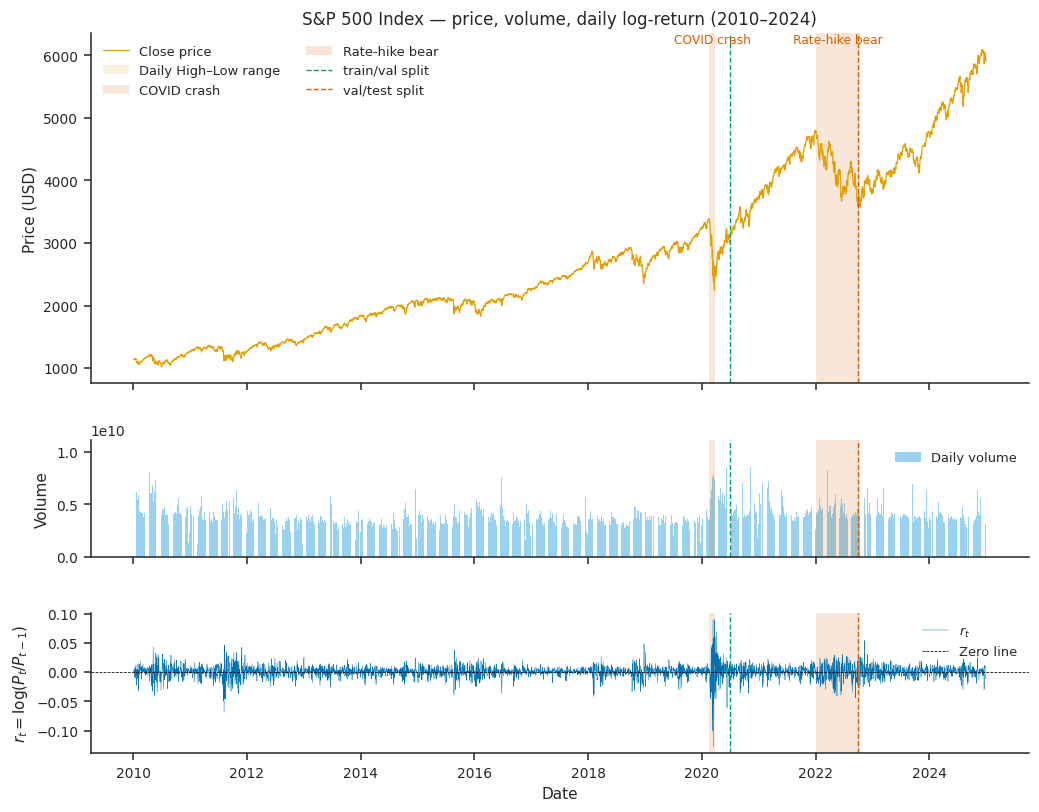

In [ ]:
import matplotlib.dates as mdates

REGIMES = [
    ("2020-02-19", "2020-03-23", "COVID crash"),
    ("2022-01-03", "2022-10-12", "Rate-hike bear"),
]

fig, axes = plt.subplots(
    3, 1, figsize=(11, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1.2], "hspace": 0.28},
)

axes[0].plot(df_raw.index, df_raw["Close"], lw=0.8, color=OKABE_ITO[0], label="Close price")
axes[0].fill_between(df_raw.index, df_raw["Low"], df_raw["High"],
                     alpha=0.15, linewidth=0, color=OKABE_ITO[0], label="Daily High–Low range")
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("S&P 500 Index — price, volume, daily log-return (2010–2024)")

axes[1].bar(df_raw.index, df_raw["Volume"], width=1.0, linewidth=0,
            alpha=0.6, color=OKABE_ITO[1], label="Daily volume")
axes[1].set_ylabel("Volume")

axes[2].plot(log_ret.index, log_ret.values, lw=0.3, color=OKABE_ITO[4], label=r"$r_t$")
axes[2].axhline(0, color="k", lw=0.5, ls="--", label="Zero line")
axes[2].set_ylabel(r"$r_t = \log(P_t/P_{t-1})$")
axes[2].set_xlabel("Date")

for start_str, end_str, label in REGIMES:
    for i, ax in enumerate(axes):
        ax.axvspan(pd.Timestamp(start_str), pd.Timestamp(end_str),
                   alpha=0.15, color=OKABE_ITO[5], linewidth=0,
                   label=label if i == 0 else None)
        if i == 0:
            mid = pd.Timestamp(start_str) + (pd.Timestamp(end_str) - pd.Timestamp(start_str)) / 2
            ax.text(mid, ax.get_ylim()[1], label, ha="center", va="top",
                    fontsize=8, color=OKABE_ITO[5])

n = len(df_raw)
for ax in axes:
    ax.axvline(df_raw.index[int(n * 0.70)], ls="--", lw=0.9, color=OKABE_ITO[2],
               label="train/val split" if ax is axes[0] else None)
    ax.axvline(df_raw.index[int(n * 0.85)], ls="--", lw=0.9, color=OKABE_ITO[5],
               label="val/test split" if ax is axes[0] else None)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[0].legend(loc="upper left", fontsize=8.5, ncol=2, framealpha=0.9)
axes[1].legend(loc="upper right", fontsize=8.5)
axes[2].legend(loc="upper right", fontsize=8.5)

sns.despine(fig)
save_fig(fig, "eda_01_overview")
plt.show()


## Descriptive Statistics Table

A formatted summary of the first four moments, annualised mean/vol and VaR/ES. Written as stdout and a one-row CSV (`results/eda/descriptives.csv`) for direct LaTeX import into the dissertation.

In [ ]:
# Descriptive statistics table
def _desc(series: pd.Series) -> dict:
    """Return a flat dict of descriptive statistics for a daily log-return series.

    Args:
        series: pandas Series of daily log-returns (scale: natural log, not percent).

    Returns:
        dict keyed by column names in the plan (n, start, end, mean_d, std_d,
        ann_mean, ann_vol, skew, excess_kurt, min, max, pos_pct, var_95, es_95).
        ``ann_mean`` / ``ann_vol`` use the 252-trading-day convention. ``var_95``
        and ``es_95`` are reported as negative numbers on the daily log-return
        scale (5th percentile and mean below the 5th percentile, respectively).
    """
    var_95 = float(np.quantile(series, 0.05))
    es_95 = float(series[series <= var_95].mean())
    return {
        "n": int(series.size),
        "start": str(series.index.min().date()),
        "end": str(series.index.max().date()),
        "mean_d": float(series.mean()),
        "std_d": float(series.std()),
        "ann_mean": float(series.mean() * 252),
        "ann_vol": float(series.std() * np.sqrt(252)),
        "skew": float(series.skew()),
        "excess_kurt": float(series.kurtosis()),
        "min": float(series.min()),
        "max": float(series.max()),
        "pos_pct": float((series > 0).mean()),
        "var_95": var_95,
        "es_95": es_95,
    }

desc = _desc(r)
desc_df = pd.DataFrame([desc])
desc_df.to_csv(FIG_DIR / "descriptives.csv", index=False)

# Styled display: float columns formatted, string columns left-aligned
float_cols = [c for c in desc_df.columns if desc_df[c].dtype == float]
display(
    desc_df.style
    .format({c: "{:+.6f}" for c in float_cols})
    .set_caption("Daily log-return descriptive statistics (^GSPC, 2010–2024)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold")]}])
)


,n,start,end,mean_d,std_d,ann_mean,ann_vol,skew,excess_kurt,min,max,pos_pct,var_95,es_95
0,3772,2010-01-05,2024-12-30,+0.000438,+0.010890,+0.110318,+0.172869,-0.726197,+13.214433,-0.127652,+0.089683,+0.544804,-0.016625,-0.026824


## Return Distribution vs Normal (fat-tail evidence)

Panel (a) shows the empirical KDE against a fitted Normal(μ,σ), with the y-axis on a log scale so tail mass is visible. Panel (b) is a QQ plot vs Normal.

Annotated with the Jarque-Bera statistic, p-value, skewness and excess kurtosis. These numbers form the quantitative case for the Heston and jump-aware models in the registry.

/tmp/ipykernel_18612/70618827.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


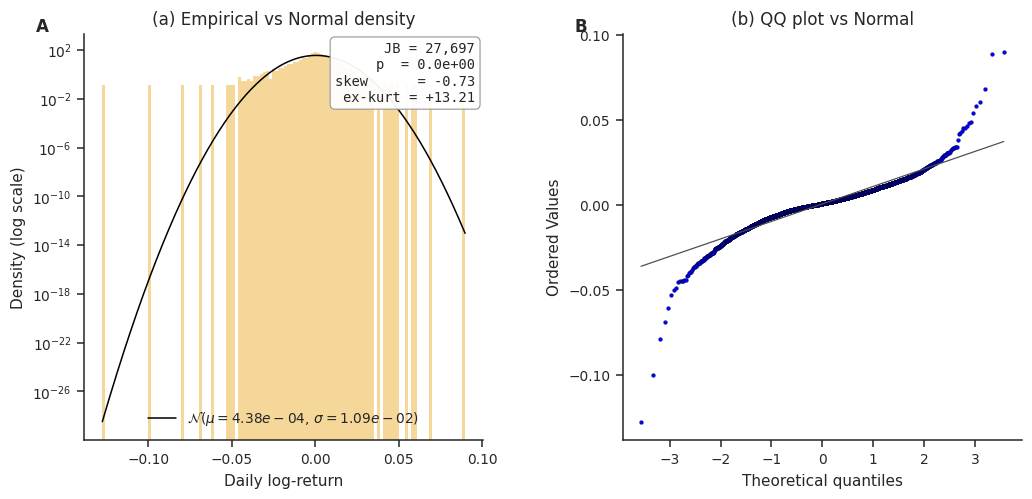

In [ ]:
# Fat-tail evidence
from scipy import stats

mu, sd = r.mean(), r.std()
jb_stat, jb_p = stats.jarque_bera(r)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"wspace": 0.35})

x = np.linspace(r.min(), r.max(), 400)
axL.hist(r, bins=120, density=True, alpha=0.4, color=OKABE_ITO[0], edgecolor="none")
axL.plot(x, stats.norm.pdf(x, mu, sd), color="k", lw=1,
         label=fr"$\mathcal{{N}}(\mu={mu:.2e},\,\sigma={sd:.2e})$")
axL.set_yscale("log")
axL.set_xlabel("Daily log-return")
axL.set_ylabel("Density (log scale)")
axL.set_title("(a) Empirical vs Normal density")
axL.legend(loc="lower center", fontsize=9)
axL.text(-0.12, 1.04, "A", transform=axL.transAxes, fontsize=11, fontweight="bold", va="top")
axL.text(
    0.98, 0.98,
    f"JB = {jb_stat:,.0f}\n"
    f"p  = {jb_p:.1e}\n"
    f"skew      = {r.skew():+.2f}\n"
    f"ex-kurt = {r.kurtosis():+.2f}",
    transform=axL.transAxes, va="top", ha="right",
    fontsize=9, family="monospace",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.6", alpha=0.95),
)

stats.probplot(r, dist="norm", plot=axR)
pts, line = axR.get_lines()[0], axR.get_lines()[1]
pts.set_marker("o"); pts.set_markersize(2.5)
pts.set_markeredgecolor("k"); pts.set_markeredgewidth(0.2)
line.set_color("0.3"); line.set_lw(0.8)
axR.set_title("(b) QQ plot vs Normal")
axR.text(-0.12, 1.04, "B", transform=axR.transAxes, fontsize=11, fontweight="bold", va="top")

sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_02_fat_tails")
plt.show()


## Figure 0.3: Stationarity Tests (ADF)

Three Augmented Dickey-Fuller tests rendered as a colour-coded table figure (reproducible in LaTeX without re-running the notebook):

| Series | Expected | Use in modelling |
|---|---|---|
| `Close` | non-stationary | Rejects pricing on raw levels |
| `log_return` | stationary | Target variable for all return models |
| `rolling_volatility_20` | stationary (mean-reverting) | Supports the OU PINN |

p-values are shaded green/red against α = 0.05.

               Series   ADF stat      p-value   crit 5%  Stationary@0.05
                Close   1.426481 9.972312e-01 -2.862313            False
           log_return -13.343764 5.849845e-25 -2.862312             True
rolling_volatility_20  -6.630734 5.723802e-09 -2.862317             True


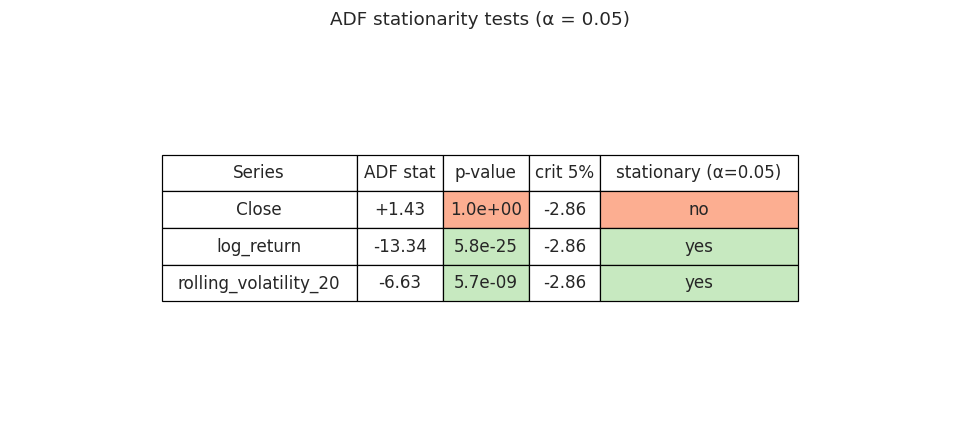

In [ ]:
from statsmodels.tsa.stattools import adfuller

series_to_test = {
    "Close": df_raw["Close"].dropna(),
    "log_return": r,
    "rolling_volatility_20": df["rolling_volatility_20"].dropna(),
}

rows = []
for name, s in series_to_test.items():
    stat, p, _, _, crit, _ = adfuller(s, autolag="AIC")
    rows.append({
        "Series": name,
        "ADF stat": stat,
        "p-value": p,
        "crit 5%": crit["5%"],
        "Stationary@0.05": p < 0.05,
    })
adf = pd.DataFrame(rows)
print(adf.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 2.2 + 0.7 * len(adf)))
ax.axis("off")
tbl = ax.table(
    cellText=[[row["Series"],
               f"{row['ADF stat']:+.2f}",
               f"{row['p-value']:.1e}",
               f"{row['crit 5%']:+.2f}",
               "yes" if row["Stationary@0.05"] else "no"]
              for row in rows],
    colLabels=["Series", "ADF stat", "p-value", "crit 5%", "stationary (α=0.05)"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)
tbl.auto_set_column_width(col=list(range(5)))

for i, row in enumerate(rows, start=1):
    colour = "#c7e9c0" if row["Stationary@0.05"] else "#fcae91"
    tbl[(i, 2)].set_facecolor(colour)
    tbl[(i, 4)].set_facecolor(colour)

ax.set_title("ADF stationarity tests (α = 0.05)", pad=14, fontsize=12)
save_fig(fig, "eda_03_stationarity")
plt.show()


## Volatility Clustering (the central PINN motivation)

A 2x3 small multiple showing ACF and PACF:
- Panels (a-c): ACF of $r_t$, $r_t^2$ and $|r_t|$ on a shared y-axis. The near-zero ACF of $r_t$ supports weak-form EMH; the strongly positive ACF of $r_t^2$ and $|r_t|$ is the volatility clustering signature.
- Panels (d-f): PACF of the same series, showing the partial autocorrelation structure needed for AR order selection.

Ljung-Box(10) and ARCH-LM(10) statistics are annotated on panel (e).

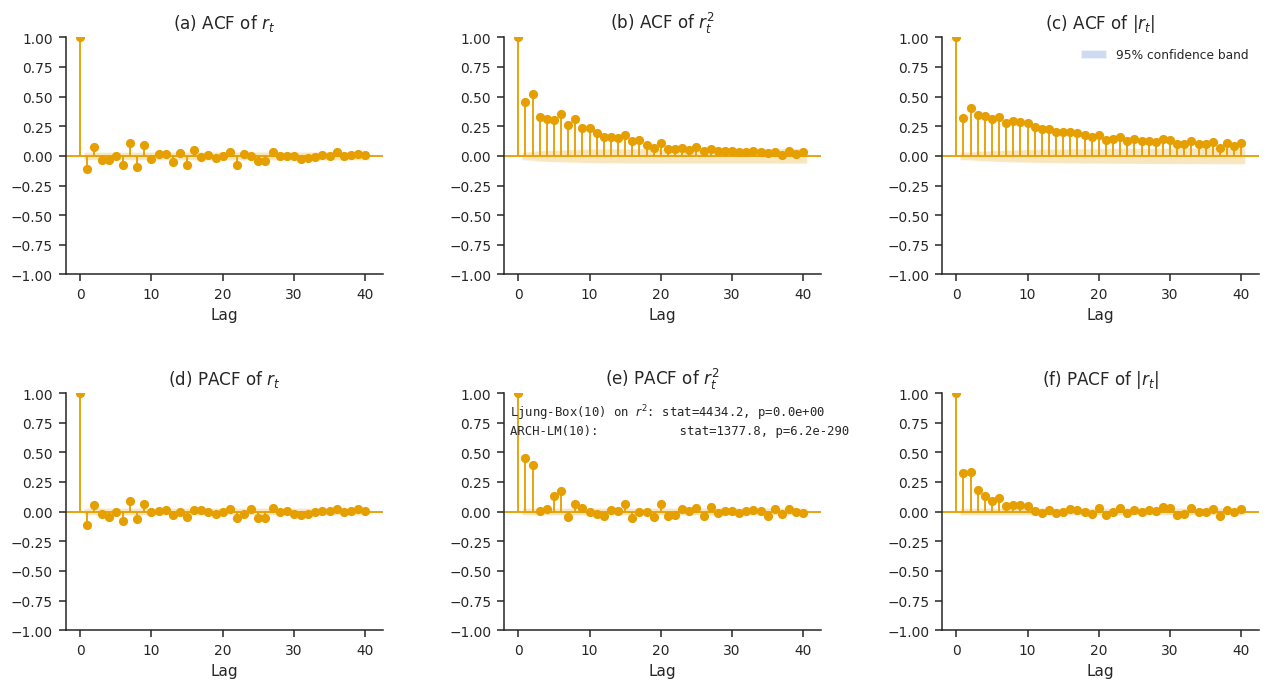

In [9]:
# Cell 7: Figure 0.4 — volatility clustering (ACF + PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 3, figsize=(14, 7.0), gridspec_kw={"hspace": 0.50, "wspace": 0.38})

plot_acf(r, lags=40, ax=axes[0, 0], title="(a) ACF of $r_t$")
plot_acf(r ** 2, lags=40, ax=axes[0, 1], title="(b) ACF of $r_t^2$")
plot_acf(r.abs(), lags=40, ax=axes[0, 2], title=r"(c) ACF of $|r_t|$")

ylim_acf = axes[0, 1].get_ylim()
for ax in (axes[0, 0], axes[0, 2]):
    ax.set_ylim(ylim_acf)

plot_pacf(r, lags=40, method="ywm", ax=axes[1, 0], title="(d) PACF of $r_t$")
plot_pacf(r ** 2, lags=40, method="ywm", ax=axes[1, 1], title="(e) PACF of $r_t^2$")
plot_pacf(r.abs(), lags=40, method="ywm", ax=axes[1, 2], title=r"(f) PACF of $|r_t|$")

ylim_pacf = axes[1, 1].get_ylim()
for ax in (axes[1, 0], axes[1, 2]):
    ax.set_ylim(ylim_pacf)

for ax in axes.flat:
    ax.set_xlabel("Lag")

lb = acorr_ljungbox(r ** 2, lags=[10], return_df=True).iloc[0]
arch_stat, arch_p, _, _ = het_arch(r, nlags=10)
axes[1, 1].text(
    0.02, 0.96,
    f"Ljung-Box(10) on $r^2$: stat={lb['lb_stat']:.1f}, p={lb['lb_pvalue']:.1e}\n"
    f"ARCH-LM(10):           stat={arch_stat:.1f}, p={arch_p:.1e}",
    transform=axes[1, 1].transAxes, va="top", fontsize=8, family="monospace",
)

# Shared legend explaining confidence band (added once, top-right panel)
ci_patch = Patch(facecolor="#5c85d6", alpha=0.3, label="95% confidence band")
axes[0, 2].legend(handles=[ci_patch], fontsize=8, loc="upper right", framealpha=0.9)

sns.despine(fig)
save_fig(fig, "eda_04_volatility_clustering")
plt.show()


## Rolling Distributional Shift

Rolling 252-day skewness and excess kurtosis. A time-stationary distribution would produce flat lines; the pronounced time-variation (especially during 2020) motivates regime-aware modelling and physics constraints on the return distribution.

/tmp/ipykernel_18612/3872426798.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


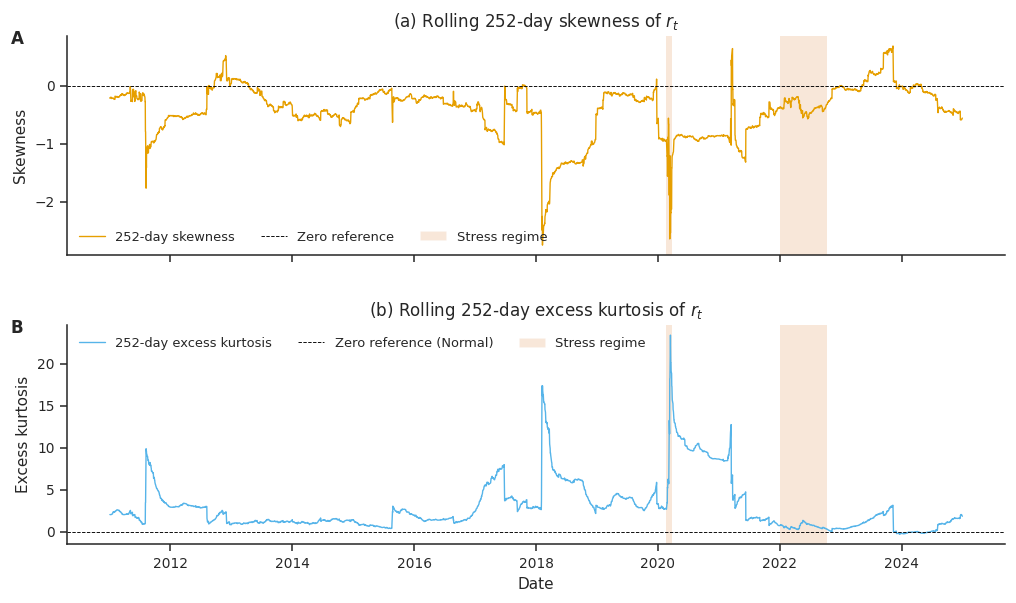

In [ ]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

WINDOW = 252

roll_skew = r.rolling(WINDOW).skew()
roll_kurt = r.rolling(WINDOW).kurt()

fig, (ax_s, ax_k) = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True,
                                  gridspec_kw={"hspace": 0.32})

ax_s.plot(roll_skew.index, roll_skew.values, lw=0.9, color=OKABE_ITO[0],
          label=f"{WINDOW}-day rolling skewness")
ax_s.axhline(0, color="k", lw=0.6, ls="--", label="Zero reference")
ax_s.set_ylabel("Skewness", fontsize=10)
ax_s.set_title(f"(a) Rolling {WINDOW}-day skewness of $r_t$")
ax_s.text(-0.06, 1.03, "A", transform=ax_s.transAxes, fontsize=11, fontweight="bold", va="top")

ax_k.plot(roll_kurt.index, roll_kurt.values, lw=0.9, color=OKABE_ITO[1],
          label=f"{WINDOW}-day rolling excess kurtosis")
ax_k.axhline(0, color="k", lw=0.6, ls="--", label="Zero reference (Normal)")
ax_k.set_ylabel("Excess kurtosis", fontsize=10)
ax_k.set_xlabel("Date")
ax_k.set_title(f"(b) Rolling {WINDOW}-day excess kurtosis of $r_t$")
ax_k.text(-0.06, 1.03, "B", transform=ax_k.transAxes, fontsize=11, fontweight="bold", va="top")

regime_patch = Patch(facecolor=OKABE_ITO[5], alpha=0.15, label="Stress regime")
for start_str, end_str, label in REGIMES:
    for ax in (ax_s, ax_k):
        ax.axvspan(pd.Timestamp(start_str), pd.Timestamp(end_str),
                   alpha=0.15, color=OKABE_ITO[5], linewidth=0)

ax_k.xaxis.set_major_locator(mdates.YearLocator(2))
ax_k.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_s.legend(handles=[*ax_s.get_lines()[:2], regime_patch],
            labels=[f"{WINDOW}-day skewness", "Zero reference", "Stress regime"],
            fontsize=8.5, loc="lower left", ncol=3, framealpha=0.9)
ax_k.legend(handles=[*ax_k.get_lines()[:2], regime_patch],
            labels=[f"{WINDOW}-day excess kurtosis", "Zero reference (Normal)", "Stress regime"],
            fontsize=8.5, loc="upper left", ncol=3, framealpha=0.9)

sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_04b_rolling_moments")
plt.show()


## Feature Correlation 

Lower-triangular correlation heatmap of engineered features, diverging palette (`vlag`) centred at 0. Cells are annotated only where |r| >= 0.5.

Below the heatmap, all pairs with |r| > 0.8 are listed and saved to `results/eda/high_corr_pairs.csv` so the Methodology chapter can justify any feature drops.

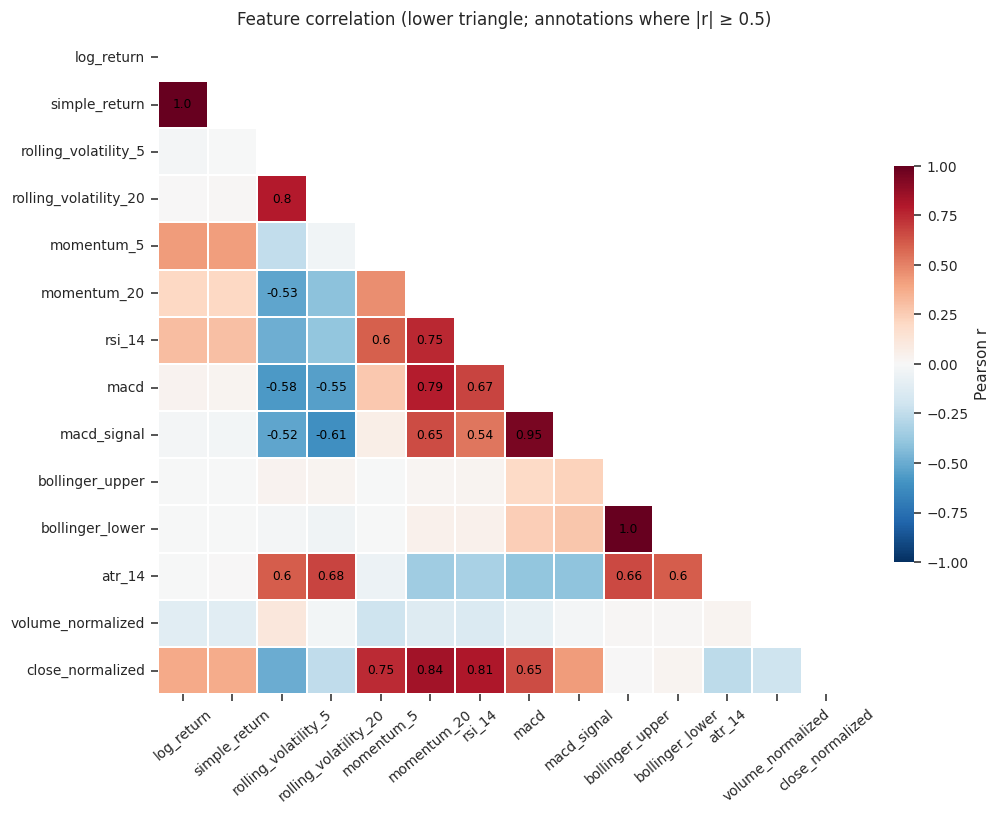

Pairs with |r| > 0.8: 5
  log_return                <-> simple_return             r = +1.000
  momentum_20               <-> close_normalized          r = +0.839
  rsi_14                    <-> close_normalized          r = +0.812
  macd                      <-> macd_signal               r = +0.946
  bollinger_upper           <-> bollinger_lower           r = +0.996


In [ ]:
FEATURES_REQUESTED = [
    "log_return", "simple_return",
    "rolling_volatility_5", "rolling_volatility_20",
    "momentum_5", "momentum_20",
    "rsi_14", "macd", "macd_signal",
    "bollinger_upper", "bollinger_lower", "atr_14",
    "volume_normalized", "close_normalized",
]
FEATURES = [f for f in FEATURES_REQUESTED if f in df.columns]
dropped = set(FEATURES_REQUESTED) - set(FEATURES)
if dropped:
    print(f"WARNING: {len(dropped)} feature(s) not found and skipped: {sorted(dropped)}")

corr = df[FEATURES].corr()
corr.index.name = None
corr.columns.name = None

mask_tri = np.triu(np.ones_like(corr, dtype=bool))
annot = corr.round(2).astype(object).where(corr.abs() >= 0.5, "")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(
    corr, mask=mask_tri, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=annot, fmt="", annot_kws={"size": 8, "color": "k"},
    linewidths=0.3, linecolor="white",
    cbar_kws={"shrink": 0.6, "label": "Pearson r"}, ax=ax,
)
ax.set_title("Feature correlation (lower triangle; annotations where |r| ≥ 0.5)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=9, rotation=40)
ax.tick_params(axis="y", labelsize=9, rotation=0)
fig.tight_layout()
save_fig(fig, "eda_05_feature_corr")
plt.show()

high = [(FEATURES[i], FEATURES[j], float(corr.iat[i, j]))
        for i in range(len(FEATURES))
        for j in range(i + 1, len(FEATURES))
        if abs(corr.iat[i, j]) > 0.8]
pd.DataFrame(high, columns=["feature_a", "feature_b", "pearson_r"]).to_csv(
    FIG_DIR / "high_corr_pairs.csv", index=False,
)
print(f"Pairs with |r| > 0.8: {len(high)}")
for a, b, r_ in high:
    print(f"  {a:25s} <-> {b:25s} r = {r_:+.3f}")


## Split and Leakage Audit

The most common dissertation-killing bug is a feature that leaks a future value. This cell constructs the train/val/test splits via the same code path as training (`TimeSeriesDataset.from_dataframe`) and asserts that feature values at index `t` do not depend on `t+1`.

19:35:12 | INFO    | src.data.dataset | Splits -> train=2567 val=503 test=503 (seq_len=60, features=16)


✓ Split alignment verified — train=2,567  val=503  test=503


/tmp/ipykernel_18612/3903132524.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_df, x="split", y="log_return",
/tmp/ipykernel_18612/3903132524.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


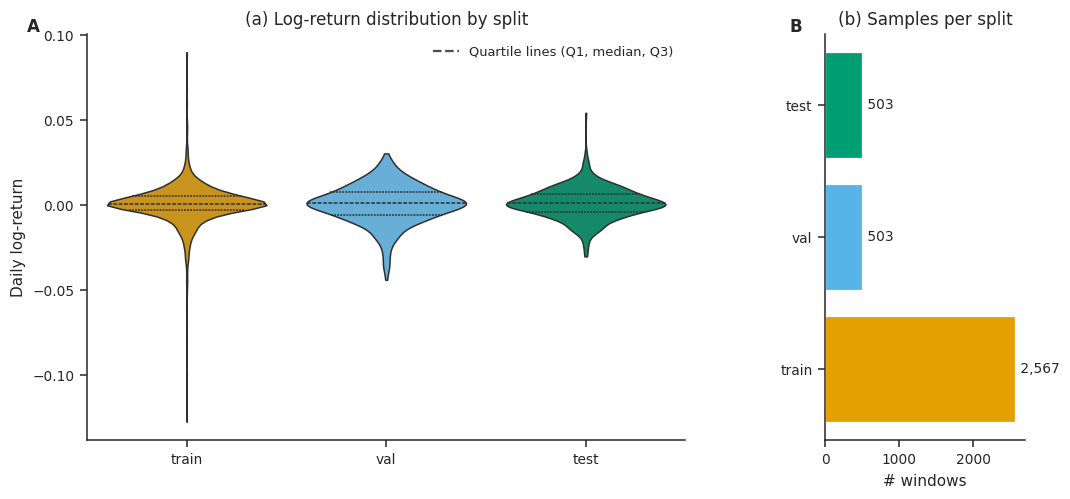

In [ ]:
import torch
from src.data.dataset import TimeSeriesDataset
from matplotlib.lines import Line2D

SEQ_LEN = 60
SPLITS = (0.70, 0.15, 0.15)

train_ds, val_ds, test_ds = TimeSeriesDataset.from_dataframe(
    df, seq_len=SEQ_LEN, target_col="log_return", split_ratios=SPLITS,
)
x, y, _ = train_ds[0]
assert x.shape[0] == SEQ_LEN, "seq_len mismatch"

for i in (0, 1, len(train_ds) - 1):
    _, yi, _ = train_ds[i]
    expected = float(df["log_return"].iloc[SEQ_LEN + i])
    assert torch.isclose(
        yi.float().squeeze(),
        torch.tensor(expected).float(),
        atol=1e-6,
    ), f"leakage / alignment error at i={i}"

print(f"\u2713 Split alignment verified — "
      f"train={len(train_ds):,}  val={len(val_ds):,}  test={len(test_ds):,}")

n = len(df)
t1 = int(n * SPLITS[0])
t2 = int(n * (SPLITS[0] + SPLITS[1]))
split_labels = ["train"] * t1 + ["val"] * (t2 - t1) + ["test"] * (n - t2)
dist_df = pd.DataFrame({"log_return": df["log_return"].values, "split": split_labels})

fig, (axV, axC) = plt.subplots(1, 2, figsize=(11, 4.8),
                                gridspec_kw={"width_ratios": [3, 1], "wspace": 0.35})
sns.violinplot(data=dist_df, x="split", y="log_return",
               order=["train", "val", "test"], inner="quartile",
               palette=[OKABE_ITO[0], OKABE_ITO[1], OKABE_ITO[2]], ax=axV, cut=0)
axV.set_title("(a) Log-return distribution by split", fontsize=11)
axV.set_xlabel("")
axV.set_ylabel("Daily log-return", fontsize=10)
axV.text(-0.10, 1.04, "A", transform=axV.transAxes, fontsize=11, fontweight="bold", va="top")

# Legend for violin inner lines
quartile_line = Line2D([0], [0], color="0.3", lw=1.5, ls="--", label="Quartile lines (Q1, median, Q3)")
axV.legend(handles=[quartile_line], fontsize=8.5, loc="upper right", framealpha=0.9)

counts = pd.Series({"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})
bars = axC.barh(counts.index, counts.values,
                color=[OKABE_ITO[0], OKABE_ITO[1], OKABE_ITO[2]])
axC.set_title("(b) Samples per split", fontsize=11)
axC.set_xlabel("# windows", fontsize=10)
for bar, v in zip(bars, counts.values):
    axC.text(v + 5, bar.get_y() + bar.get_height() / 2,
             f" {v:,}", va="center", fontsize=9)
axC.text(-0.18, 1.04, "B", transform=axC.transAxes, fontsize=11, fontweight="bold", va="top")

sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_06_split")
plt.show()


## VIX EDA

The CBOE Volatility Index (VIX) measures 30-day implied volatility of S&P 500 options and is the primary fear gauge used in the PINN physics constraints. 

## VIX Fetch and Integrity Audit

Fetches `^VIX` daily close via `DataFetcher.fetch_close`, aligns to the S&P 500 calendar and runs the same hard assertions as Cell 2.

In [ ]:
if hasattr(fetcher, "fetch_close"):
    vix_raw = fetcher.fetch_close("^VIX", START, END)
else:
    print("fetch_close not found — using fetch() fallback (restart runtime to silence this)")
    _df_vix = fetcher.fetch("^VIX", START, END)
    vix_raw = _df_vix["Close"]

# Integrity assertions
assert vix_raw.index.is_monotonic_increasing, "VIX dates not sorted"
assert vix_raw.index.is_unique, "VIX duplicate dates"
assert (vix_raw > 0).all(), "VIX has non-positive values"
assert vix_raw.isna().sum() == 0, "VIX has NaN values"

# Align to S&P 500 calendar (inner join — only trading days present in both)
vix = vix_raw.reindex(df_raw.index).dropna()
missing = df_raw.index.difference(vix.index)
if len(missing):
    print(f"WARNING: {len(missing)} S&P 500 dates not in VIX (dropped): {missing[:5].tolist()}")

# log-VIX and daily log-changes for downstream analysis
log_vix = np.log(vix)
vix_ret = log_vix.diff().dropna()

print(f"VIX observations : {len(vix):,}")
print(f"Date range       : {vix.index[0].date()} -> {vix.index[-1].date()}")
print(f"Level — min: {vix.min():.2f}  median: {vix.median():.2f}  max: {vix.max():.2f}")
print(f"\nRegime counts (standard VIX thresholds):")
print(f"  calm    (<15)  : {(vix < 15).sum():5d} days  ({(vix < 15).mean():.1%})")
print(f"  normal  (15-25): {((vix >= 15) & (vix < 25)).sum():5d} days  ({((vix >= 15) & (vix < 25)).mean():.1%})")
print(f"  stress  (25-40): {((vix >= 25) & (vix < 40)).sum():5d} days  ({((vix >= 25) & (vix < 40)).mean():.1%})")
print(f"  extreme (>=40) : {(vix >= 40).sum():5d} days  ({(vix >= 40).mean():.1%})")


19:35:13 | INFO    | src.data.fetcher | Fetching ^VIX close from yfinance (2010-01-01 -> 2024-12-31)
19:35:13 | INFO    | src.data.fetcher | Cached 3773 rows -> VIX_close_2010-01-01_2024-12-31.parquet


VIX observations : 3,773
Date range       : 2010-01-04 -> 2024-12-30
Level — min: 9.14  median: 16.60  max: 82.69

Regime counts (standard VIX thresholds):
  calm    (<15)  :  1411 days  (37.4%)
  normal  (15-25):  1839 days  (48.7%)
  stress  (25-40):   473 days  (12.5%)
  extreme (>=40) :    50 days  (1.3%)


## VIX Level Overview

VIX time series with four regime bands shaded and labelled. Vertical dashed lines mark the train/val/test split boundaries. A twin-axis rolling 20-day VIX is overlaid to show mean-reversion tendency.

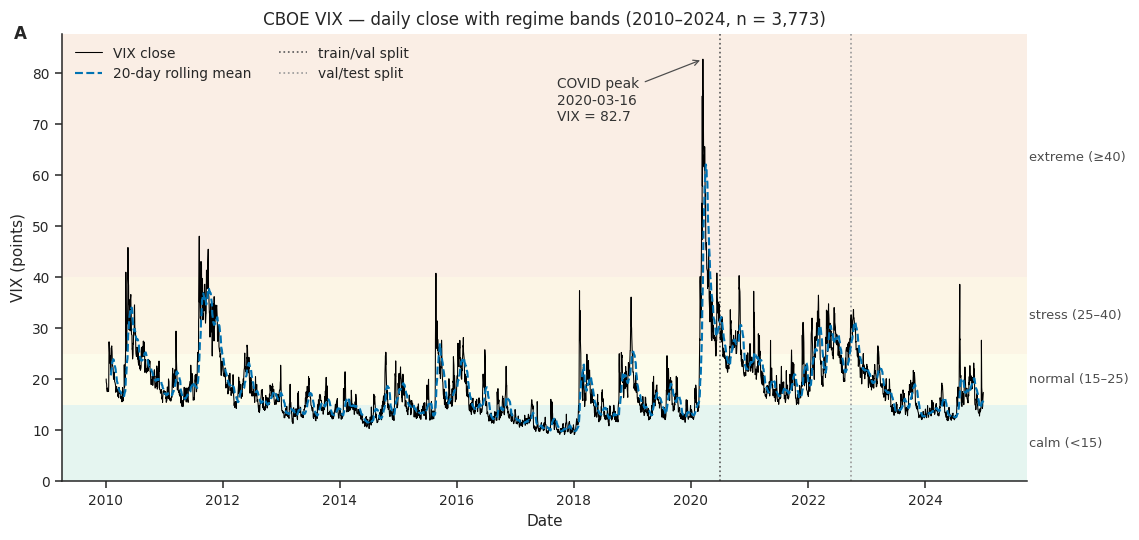

In [ ]:
import matplotlib.dates as mdates

VIX_REGIMES = [
    (0,  15, OKABE_ITO[2], "calm (<15)"),
    (15, 25, OKABE_ITO[3], "normal (15–25)"),
    (25, 40, OKABE_ITO[0], "stress (25–40)"),
    (40, 90, OKABE_ITO[5], "extreme (≥40)"),
]

fig, ax = plt.subplots(figsize=(11, 5.0))

for lo, hi, col, label in VIX_REGIMES:
    ax.axhspan(lo, hi, alpha=0.10, color=col, linewidth=0)
    mid = (lo + min(hi, vix.max() * 1.05)) / 2
    ax.text(1.002, mid, label, transform=ax.get_yaxis_transform(),
            va="center", ha="left", fontsize=8.5, color="0.3")

ax.plot(vix.index, vix.values, lw=0.7, color="k", zorder=3, label="VIX close")
ax.plot(vix.index, vix.rolling(20).mean().values, lw=1.4,
        color=OKABE_ITO[4], ls="--", label="20-day rolling mean", zorder=4)

n_vix = len(vix)
ax.axvline(vix.index[int(n_vix * 0.70)], ls=":", lw=1.1, color="0.35", label="train/val split")
ax.axvline(vix.index[int(n_vix * 0.85)], ls=":", lw=1.1, color="0.60", label="val/test split")

covid_peak_idx = vix.idxmax()
ax.annotate(
    f"COVID peak\n{covid_peak_idx.date()}\nVIX = {vix.max():.1f}",
    xy=(covid_peak_idx, vix.max()),
    xytext=(covid_peak_idx - pd.DateOffset(months=30), vix.max() - 12),
    arrowprops=dict(arrowstyle="->", lw=0.8, color="0.3"),
    fontsize=9, color="0.2",
)

ax.set_ylim(0, vix.max() * 1.06)
ax.set_ylabel("VIX (points)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title(f"CBOE VIX — daily close with regime bands (2010–2024, n = {len(vix):,})")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9, ncol=2)
ax.text(-0.05, 1.02, "A", transform=ax.transAxes, fontsize=11, fontweight="bold", va="top")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

sns.despine(fig)
fig.tight_layout(rect=[0, 0, 0.95, 1])
save_fig(fig, "eda_v1_vix_overview")
plt.show()


## VIX Distribution 

VIX is right-skewed and leptokurtic, the opposite sign to return skewness. Panel (a) shows the empirical density against a log-Normal fit (the standard model for implied vol). Panel (b) is a QQ plot vs log-Normal to diagnose tail excess.

/tmp/ipykernel_18612/2473402824.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


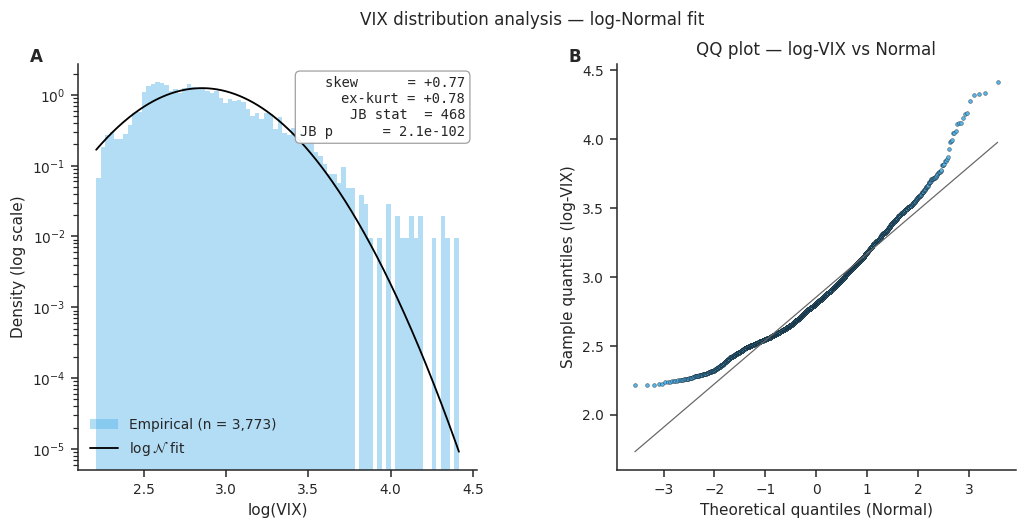

In [ ]:
from scipy import stats as scipy_stats

lv = log_vix.dropna()
mu_lv, sd_lv = lv.mean(), lv.std()
jb_stat_v, jb_p_v = scipy_stats.jarque_bera(lv)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"wspace": 0.35})

# (A) empirical density vs log-Normal fit
x_lv = np.linspace(lv.min(), lv.max(), 400)
axL.hist(lv, bins=80, density=True, alpha=0.45, color=OKABE_ITO[1], edgecolor="none",
         label=f"Empirical (n = {len(lv):,})")
axL.plot(x_lv, scipy_stats.norm.pdf(x_lv, mu_lv, sd_lv),
         color="k", lw=1.2, label=r"$\log\mathcal{N}$ fit")
axL.set_yscale("log")
axL.set_xlabel("log(VIX)", fontsize=10)
axL.set_ylabel("Density (log scale)", fontsize=10)

# Legend in lower-left — clear of the stats box in the upper-right
axL.legend(fontsize=9, loc="lower left", framealpha=0.9)

# Stats annotation in upper-right only (no legend clash)
axL.text(
    0.97, 0.97,
    f"skew      = {lv.skew():+.2f}\n"
    f"ex-kurt = {lv.kurtosis():+.2f}\n"
    f"JB stat  = {jb_stat_v:,.0f}\n"
    f"JB p      = {jb_p_v:.1e}",
    transform=axL.transAxes, va="top", ha="right",
    fontsize=9, family="monospace",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.6", alpha=0.95),
)
axL.text(-0.12, 1.04, "A", transform=axL.transAxes, fontsize=11, fontweight="bold", va="top")

# (B) QQ plot
scipy_stats.probplot(lv, dist="norm", plot=axR)
pts, line = axR.get_lines()[0], axR.get_lines()[1]
pts.set_marker("o"); pts.set_markersize(2.5)
pts.set_markeredgecolor("k"); pts.set_markeredgewidth(0.2)
pts.set_markerfacecolor(OKABE_ITO[1])
line.set_color("0.4"); line.set_lw(0.8)
axR.set_xlabel("Theoretical quantiles (Normal)", fontsize=10)
axR.set_ylabel("Sample quantiles (log-VIX)", fontsize=10)
axR.set_title("QQ plot — log-VIX vs Normal")
axR.text(-0.12, 1.04, "B", transform=axR.transAxes, fontsize=11, fontweight="bold", va="top")

fig.suptitle("VIX distribution analysis — log-Normal fit", fontsize=11)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_v2_vix_distribution")
plt.show()


## VIX vs S&P 500 Returns (Leverage Effect)

The leverage effect is the empirically observed negative contemporaneous correlation between equity returns and implied volatility. Panel (a) shows a scatter of $r_t$ vs VIX change with an OLS fit. Panel (b) shows the rolling 63-day Pearson correlation, which should be persistently negative.

/tmp/ipykernel_18612/3946494961.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


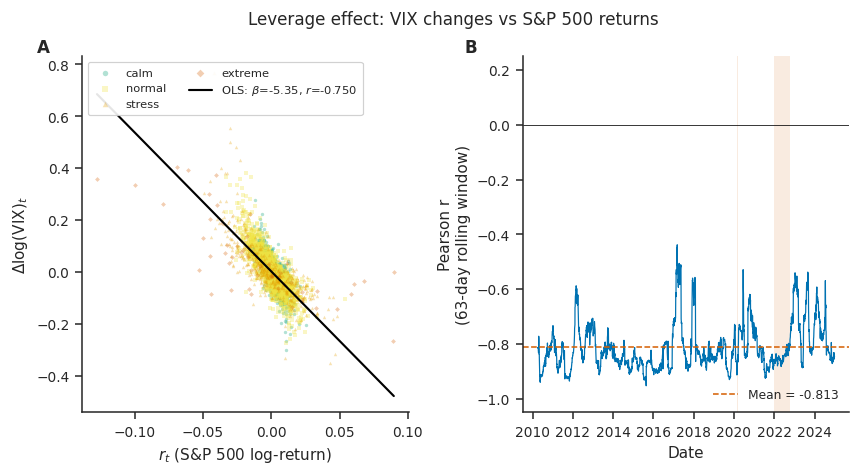

Leverage effect (n = 3,772 trading days):
  Pearson r(r_t, Δlog VIX_t) = -0.7503  (p = 0.0e+00)
  OLS slope β                = -5.3514
  Rolling mean correlation    = -0.8130


In [16]:
# Cell V.4: Figure V.3 — leverage effect (VIX change vs S&P return)
shared_idx = vix_ret.index.intersection(log_ret.dropna().index)
vr = vix_ret.loc[shared_idx]
sp = log_ret.loc[shared_idx]

slope, intercept, rval, pval, _ = scipy_stats.linregress(sp.values, vr.values)

fig, (axS, axR) = plt.subplots(1, 2, figsize=(9.0, 4.2),
                                gridspec_kw={"wspace": 0.35})

# (A) scatter — colour + marker shape encode VIX regime (redundant encoding)
regime_bins = pd.cut(
    vix.loc[shared_idx],
    bins=[0, 15, 25, 40, 999],
    labels=["calm", "normal", "stress", "extreme"],
)
regime_style = {
    "calm":    (OKABE_ITO[2], "o"),
    "normal":  (OKABE_ITO[3], "s"),
    "stress":  (OKABE_ITO[0], "^"),
    "extreme": (OKABE_ITO[5], "D"),
}
for reg, (col, marker) in regime_style.items():
    mask = regime_bins == reg
    axS.scatter(sp[mask], vr[mask], s=5, alpha=0.30, color=col,
                marker=marker, linewidths=0, rasterized=True, label=reg)

# OLS line clipped to data x-range
x_fit = np.array([sp.min(), sp.max()])
axS.plot(x_fit, intercept + slope * x_fit, color="k", lw=1.4, zorder=5,
         label=fr"OLS: $\beta$={slope:.2f}, $r$={rval:.3f}")

axS.set_xlabel(r"$r_t$ (S&P 500 log-return)")
axS.set_ylabel(r"$\Delta\log(\mathrm{VIX})_t$")
# Legend outside panel A, above it
axS.legend(fontsize=7.5, markerscale=1.6, frameon=True, framealpha=0.9,
           loc="upper left", ncol=2, borderpad=0.5)
axS.text(-0.14, 1.05, "A", transform=axS.transAxes,
         fontsize=11, fontweight="bold", va="top")

# (B) rolling 63-day Pearson correlation
roll_corr = sp.rolling(63).corr(vr)
axR.plot(roll_corr.index, roll_corr.values, lw=0.8, color=OKABE_ITO[4])
axR.axhline(0, color="k", lw=0.5)
axR.axhline(roll_corr.mean(), color=OKABE_ITO[5], lw=1.0, ls="--",
            label=f"Mean = {roll_corr.mean():.3f}")
axR.set_ylim(-1.05, 0.25)
axR.set_ylabel("Pearson r\n(63-day rolling window)")
axR.set_xlabel("Date")
axR.legend(fontsize=8, loc="lower right")
axR.text(-0.18, 1.05, "B", transform=axR.transAxes,
         fontsize=11, fontweight="bold", va="top")
axR.xaxis.set_major_locator(mdates.YearLocator(2))
axR.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for start_str, end_str, _ in REGIMES:
    axR.axvspan(pd.Timestamp(start_str), pd.Timestamp(end_str),
                alpha=0.12, color=OKABE_ITO[5], linewidth=0)

fig.suptitle("Leverage effect: VIX changes vs S&P 500 returns", fontsize=11)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_v3_leverage_effect")
plt.show()

print(f"Leverage effect (n = {len(sp):,} trading days):")
print(f"  Pearson r(r_t, Δlog VIX_t) = {rval:+.4f}  (p = {pval:.1e})")
print(f"  OLS slope β                = {slope:+.4f}")
print(f"  Rolling mean correlation    = {roll_corr.mean():+.4f}")


## VIX Regime Clustering (ACF and Persistence)

VIX exhibits long memory: high-vol periods cluster for weeks or months, not days. Panel (a) shows the ACF of VIX level (testing for mean-reversion). Panel (b) shows the ACF of |ΔVIX| (testing for vol-of-vol clustering). Panel (c) is a regime-persistence bar showing the fraction of days that remain in the same regime as the previous day.

/tmp/ipykernel_18612/1535147679.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


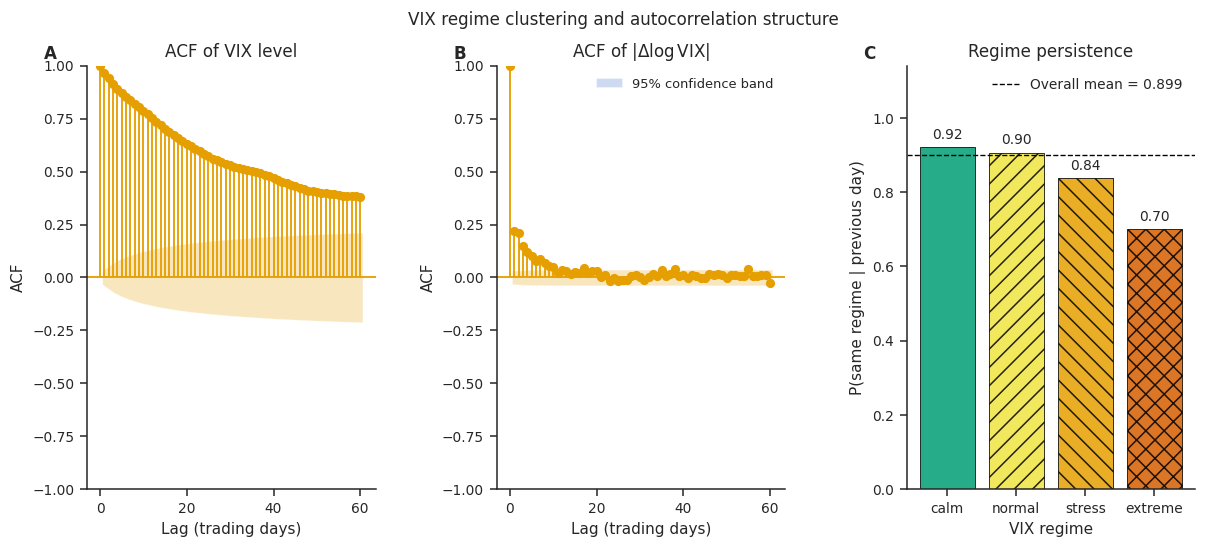

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from matplotlib.patches import Patch

regime_series = pd.cut(vix, bins=[0, 15, 25, 40, 999],
                       labels=["calm", "normal", "stress", "extreme"])
same_regime = (regime_series == regime_series.shift(1)).dropna()
persistence_overall = same_regime.mean()

pers_by_regime = {}
for reg in ["calm", "normal", "stress", "extreme"]:
    mask = regime_series.shift(1) == reg
    pers_by_regime[reg] = same_regime[mask].mean() if mask.any() else float("nan")

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw={"wspace": 0.42})

sm_plot_acf(vix, lags=60, ax=axes[0])
axes[0].set_xlabel("Lag (trading days)", fontsize=10)
axes[0].set_ylabel("ACF", fontsize=10)
axes[0].set_title("ACF of VIX level")
axes[0].text(-0.15, 1.05, "A", transform=axes[0].transAxes,
             fontsize=11, fontweight="bold", va="top")

sm_plot_acf(vix_ret.abs(), lags=60, ax=axes[1])
axes[1].set_xlabel("Lag (trading days)", fontsize=10)
axes[1].set_ylabel("ACF", fontsize=10)
axes[1].set_title(r"ACF of $|\Delta\log\mathrm{VIX}|$")
axes[1].text(-0.15, 1.05, "B", transform=axes[1].transAxes,
             fontsize=11, fontweight="bold", va="top")

# Shared legend for ACF confidence band (shown on panel B)
ci_patch = Patch(facecolor="#5c85d6", alpha=0.3, label="95% confidence band")
axes[1].legend(handles=[ci_patch], fontsize=8.5, loc="upper right", framealpha=0.9)

labels = list(pers_by_regime.keys())
vals = [pers_by_regime[k] for k in labels]
colors = [OKABE_ITO[2], OKABE_ITO[3], OKABE_ITO[0], OKABE_ITO[5]]
hatches = ["", "//", "\\\\", "xx"]
bars = axes[2].bar(labels, vals, color=colors, alpha=0.85,
                   edgecolor="k", linewidth=0.6)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
axes[2].axhline(persistence_overall, color="k", lw=0.9, ls="--",
                label=f"Overall mean = {persistence_overall:.3f}")
axes[2].set_ylim(0, 1.14)
axes[2].set_ylabel("P(same regime | previous day)", fontsize=10)
axes[2].set_xlabel("VIX regime", fontsize=10)
axes[2].legend(fontsize=9, loc="upper right")
axes[2].set_title("Regime persistence")
axes[2].text(-0.15, 1.05, "C", transform=axes[2].transAxes,
             fontsize=11, fontweight="bold", va="top")
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.016,
                 f"{v:.2f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("VIX regime clustering and autocorrelation structure", fontsize=11)
sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_v4_vix_clustering")
plt.show()


## Stationarity Tests (ADF on VIX level, log-VIX and ΔVIX)

VIX level is typically non-stationary (slow ACF decay above). Log-VIX may be borderline. First-difference of log-VIX should be stationary. This informs whether the OU PINN should operate on VIX level, log-VIX or changes.

,Series,ADF stat,p-value,crit 5%,Stationary (a=0.05)
0,VIX level,-5.207,8.51e-06,-2.862,True
1,log-VIX,-5.815,4.32e-07,-2.862,True
2,dlog-VIX (daily change),-24.235,0.00e+00,-2.862,True


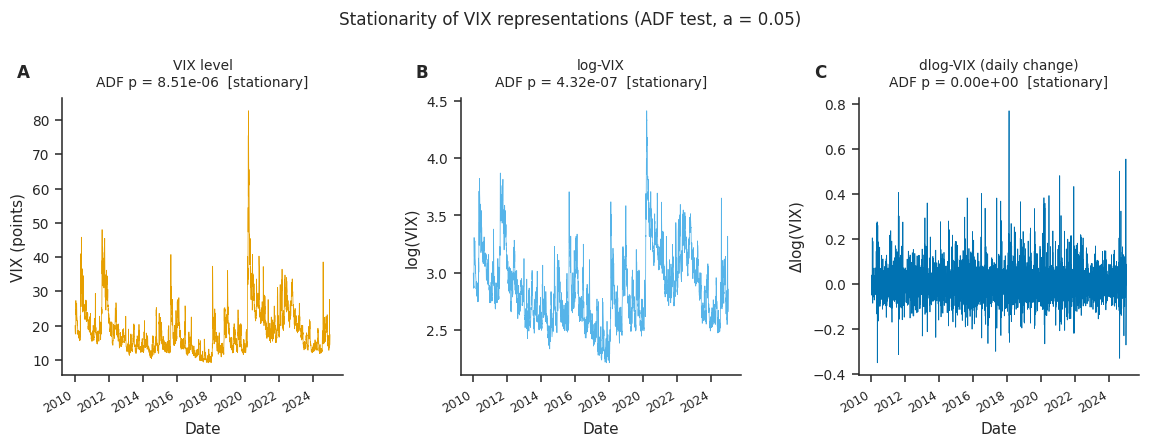

Saved: results/eda/vix_adf_results.csv


In [18]:
# Cell V.6: Figure V.5 — ADF stationarity for VIX representations
from statsmodels.tsa.stattools import adfuller
import matplotlib.dates as mdates

vix_series = {
    "VIX level": vix,
    "log-VIX": log_vix.dropna(),
    "dlog-VIX (daily change)": vix_ret,
}

rows_v = []
for name, s in vix_series.items():
    stat, p, _, _, crit, _ = adfuller(s, autolag="AIC")
    rows_v.append({
        "Series": name,
        "ADF stat": stat,
        "p-value": p,
        "crit 5%": crit["5%"],
        "Stationary (a=0.05)": p < 0.05,
    })

adf_v = pd.DataFrame(rows_v)
display(
    adf_v.style
    .format({"ADF stat": "{:+.3f}", "p-value": "{:.2e}", "crit 5%": "{:+.3f}"})
    .map(lambda v: "background-color: #c7e9c0" if v is True
         else ("background-color: #fcae91" if v is False else ""),
         subset=["Stationary (a=0.05)"])
    .set_caption("ADF stationarity tests — VIX representations (a = 0.05)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold")]}])
)

fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.2),
                         gridspec_kw={"wspace": 0.42})
# Reserve top margin so suptitle and panel letters don't collide.
# Do NOT call tight_layout() after subplots_adjust() — they conflict.
fig.subplots_adjust(top=0.78, left=0.08, right=0.97, bottom=0.18)

ylabels = ["VIX (points)", "log(VIX)", r"$\Delta\log(\mathrm{VIX})$"]
colors_v = [OKABE_ITO[0], OKABE_ITO[1], OKABE_ITO[4]]
panel_letters = ["A", "B", "C"]

for i, (name, s, col, row, ylab, letter) in enumerate(
    zip(vix_series.keys(), vix_series.values(),
        colors_v, rows_v, ylabels, panel_letters)
):
    axes[i].plot(s.index, s.values, lw=0.5, color=col)
    stat_str = "stationary" if row["Stationary (a=0.05)"] else "non-stationary"
    axes[i].set_title(
        f"{name}\nADF p = {row['p-value']:.2e}  [{stat_str}]",
        fontsize=9, pad=8,
    )
    axes[i].set_xlabel("Date", fontsize=10)
    axes[i].set_ylabel(ylab, fontsize=10)
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha="right", fontsize=8)
    axes[i].text(-0.16, 1.06, letter, transform=axes[i].transAxes,
                 fontsize=11, fontweight="bold", va="bottom")

fig.suptitle("Stationarity of VIX representations (ADF test, a = 0.05)",
             fontsize=11, y=0.97)

sns.despine(fig)
save_fig(fig, "eda_v5_vix_stationarity")
plt.show()

pd.DataFrame(rows_v).to_csv(FIG_DIR / "vix_adf_results.csv", index=False)
print("Saved: results/eda/vix_adf_results.csv")


## TNX EDA: 10-Year Treasury Yield

TNX captures the prevailing risk-free rate regime. The walk-forward test period (2018-2023) spans a full rate cycle: near-zero post-GFC levels, emergency cuts in 2020 and the fastest hiking cycle in 40 years during 2022-2023. This makes TNX a structurally distinct macro dimension from VIX and S&P price momentum.

In [ ]:
tnx = fetcher.fetch_close('^TNX', start='2010-01-01', end='2024-12-31')

# Align to S&P 500 calendar
tnx = tnx.reindex(df_raw.index).ffill().bfill()

assert tnx.isna().sum() == 0, "TNX has unexpected NaNs after alignment"
assert (tnx > 0).all(), "TNX must be positive (percentage-point yield)"
assert len(tnx) == len(df_raw), f"TNX length mismatch: {len(tnx)} vs {len(df_raw)}"

print(f"TNX rows  : {len(tnx):,}")
print(f"TNX range : {tnx.index[0].date()} → {tnx.index[-1].date()}")
print(f"TNX stats : min={tnx.min():.2f}%  max={tnx.max():.2f}%  mean={tnx.mean():.2f}%")

19:35:23 | INFO    | src.data.fetcher | Fetching ^TNX close from yfinance (2010-01-01 -> 2024-12-31)
19:35:24 | INFO    | src.data.fetcher | Cached 3771 rows -> TNX_close_2010-01-01_2024-12-31.parquet


TNX rows  : 3,773
TNX range : 2010-01-04 → 2024-12-30
TNX stats : min=0.50%  max=4.99%  mean=2.49%


### TNX Level with Rate-Regime Bands

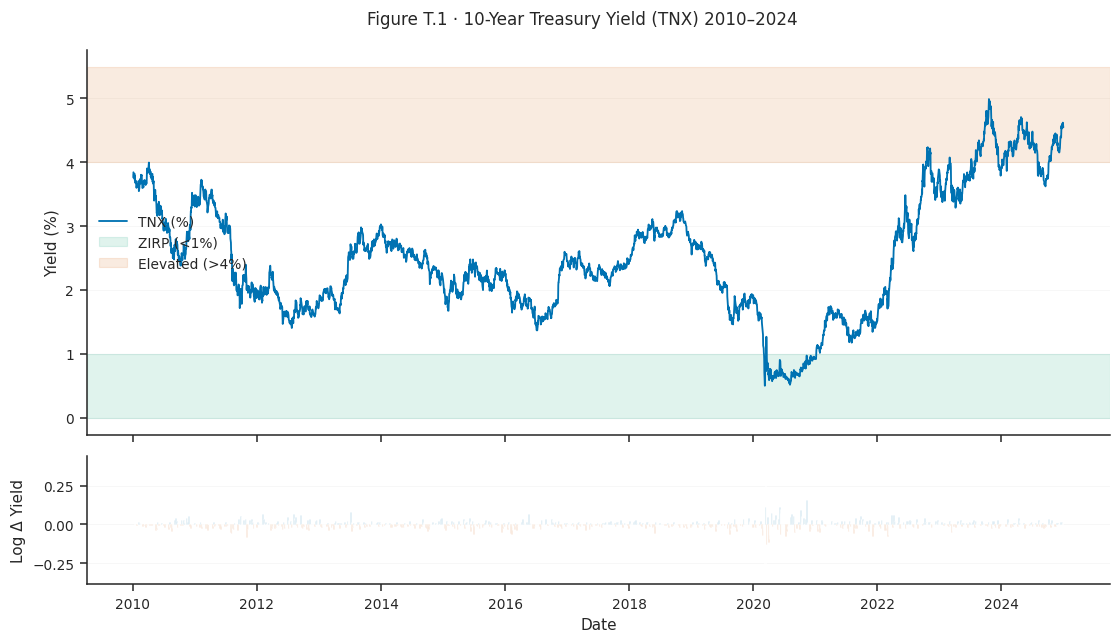

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Figure T.1 · 10-Year Treasury Yield (TNX) 2010–2024', fontsize=11)
fig.subplots_adjust(top=0.92, hspace=0.08)

ax_level, ax_change = axes

# Panel A — yield level with regime shading
ax_level.plot(tnx.index, tnx.values, color=OKABE_ITO[4], lw=1.2, label='TNX (%)')
ax_level.axhspan(0, 1.0, alpha=0.12, color=OKABE_ITO[2], label='ZIRP (<1%)')
ax_level.axhspan(4.0, tnx.max() + 0.5, alpha=0.12, color=OKABE_ITO[5], label='Elevated (>4%)')
ax_level.set_ylabel('Yield (%)')
# Legend placed between the two shaded bands to avoid overlap
ax_level.legend(loc='center left', fontsize=9, framealpha=0.9)
ax_level.grid(axis='y', alpha=0.20, linewidth=0.5)

# Panel B — daily log-change
tnx_change = np.log(tnx / tnx.shift(1)).dropna()
bar_colors = np.where(tnx_change.values >= 0, OKABE_ITO[4], OKABE_ITO[5])
ax_change.bar(tnx_change.index, tnx_change.values,
              color=bar_colors, width=1, alpha=0.7, rasterized=True)
ax_change.set_ylabel('Log Δ Yield')
ax_change.set_xlabel('Date')
ax_change.grid(axis='y', alpha=0.20, linewidth=0.5)
ax_change.xaxis.set_major_locator(mdates.YearLocator(2))
ax_change.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

sns.despine(fig)
save_fig(fig, 'eda_t1_tnx_level_overview')
plt.show()

### TNX Change vs S&P 500 Returns

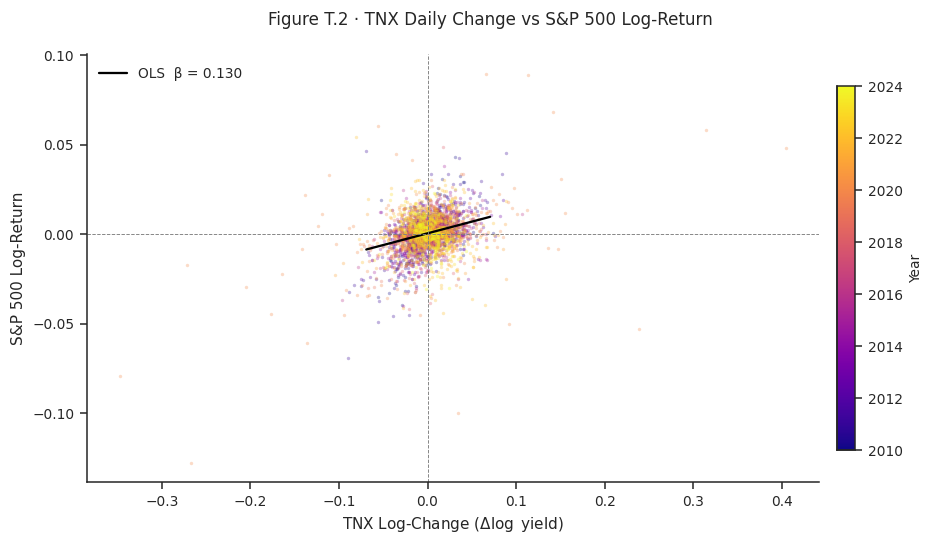

In [ ]:
shared = df['log_return'].index.intersection(tnx_change.index)
ret_aligned = df['log_return'].loc[shared]
chg_aligned = tnx_change.loc[shared]
years = ret_aligned.index.year

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure T.2 · TNX Daily Change vs S&P 500 Log-Return', fontsize=11)

# plasma is perceptually uniform and monotonically lightening — safe for year encoding
cmap = plt.get_cmap('plasma')
year_vals = years.unique()
norm = plt.Normalize(year_vals.min(), year_vals.max())

for yr in year_vals:
    mask = (years == yr)
    ax.scatter(chg_aligned[mask], ret_aligned[mask],
               s=5, alpha=0.30, color=cmap(norm(yr)),
               rasterized=True, linewidths=0)

# OLS line
m, b = np.polyfit(chg_aligned, ret_aligned, 1)
x_range = np.linspace(chg_aligned.quantile(0.01), chg_aligned.quantile(0.99), 100)
ax.plot(x_range, m * x_range + b, color='black', lw=1.5,
        label=f'OLS  β = {m:.3f}')

ax.set_xlabel(r'TNX Log-Change ($\Delta\log$ yield)', fontsize=10)
ax.set_ylabel('S&P 500 Log-Return', fontsize=10)
ax.axhline(0, color='grey', lw=0.6, ls='--')
ax.axvline(0, color='grey', lw=0.6, ls='--')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Year', fontsize=9)

sns.despine(fig)
fig.tight_layout()
save_fig(fig, 'eda_t2_tnx_vs_returns')
plt.show()

### Cell T.4: Figure T.3: TNX ACF, Regime Clustering and Stationarity
Three panels:
- **(A)** ACF of TNX level: tests for mean-reversion vs unit-root-like persistence (slow decay suggests the OU PINN should work on yield changes, not levels).
- **(B)** ACF of |Δlog TNX|: tests vol-of-vol clustering in yield changes.
- **(C)** ADF stationarity table across three representations: TNX level, log-TNX and Δlog-TNX.

Slow ACF decay combined with ADF non-stationarity argues for modelling yield changes rather than levels in the physics constraints.

/tmp/ipykernel_18612/1856698226.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


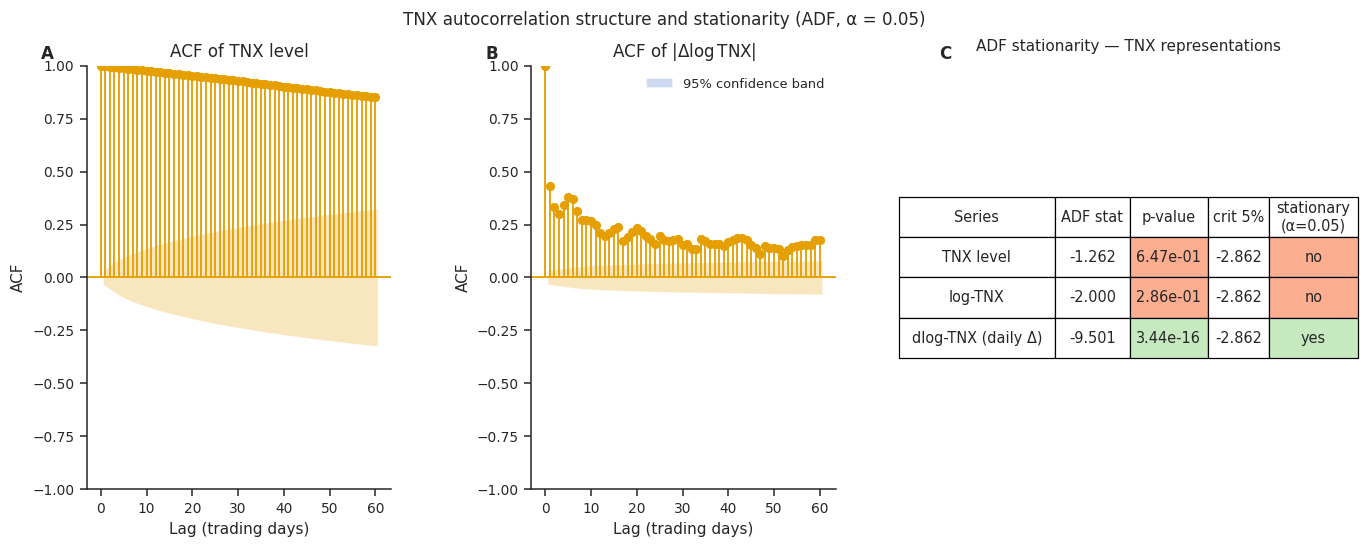


TNX ADF results:
  TNX level               ADF=-1.262  p=6.47e-01  stationary=no
  log-TNX                 ADF=-2.000  p=2.86e-01  stationary=no
  dlog-TNX (daily Δ)      ADF=-9.501  p=3.44e-16  stationary=yes


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from statsmodels.tsa.stattools import adfuller
from matplotlib.patches import Patch

log_tnx = np.log(tnx)
tnx_change = np.log(tnx / tnx.shift(1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 5.0),
                         gridspec_kw={"wspace": 0.46})
fig.suptitle("TNX autocorrelation structure and stationarity (ADF, α = 0.05)",
             fontsize=11)

# (A) ACF of TNX level
sm_plot_acf(tnx, lags=60, ax=axes[0])
axes[0].set_xlabel("Lag (trading days)", fontsize=10)
axes[0].set_ylabel("ACF", fontsize=10)
axes[0].set_title("ACF of TNX level")
axes[0].text(-0.15, 1.05, "A", transform=axes[0].transAxes,
             fontsize=11, fontweight="bold", va="top")

# (B) ACF of |Δlog TNX|
sm_plot_acf(tnx_change.abs(), lags=60, ax=axes[1])
axes[1].set_xlabel("Lag (trading days)", fontsize=10)
axes[1].set_ylabel("ACF", fontsize=10)
axes[1].set_title(r"ACF of $|\Delta\log\mathrm{TNX}|$")
axes[1].text(-0.15, 1.05, "B", transform=axes[1].transAxes,
             fontsize=11, fontweight="bold", va="top")
ci_patch = Patch(facecolor="#5c85d6", alpha=0.3, label="95% confidence band")
axes[1].legend(handles=[ci_patch], fontsize=8.5, loc="upper right", framealpha=0.9)

# (C) ADF stationarity table
tnx_series = {
    "TNX level":           tnx,
    "log-TNX":             log_tnx.dropna(),
    "dlog-TNX (daily Δ)": tnx_change,
}
rows_t = []
for name, s in tnx_series.items():
    stat, p, _, _, crit, _ = adfuller(s, autolag="AIC")
    rows_t.append({
        "Series": name,
        "ADF stat": f"{stat:+.3f}",
        "p-value": f"{p:.2e}",
        "crit 5%": f"{crit['5%']:+.3f}",
        "Stationary": p < 0.05,
    })

axes[2].axis("off")
tbl = axes[2].table(
    cellText=[[r["Series"], r["ADF stat"], r["p-value"],
               r["crit 5%"], "yes" if r["Stationary"] else "no"]
              for r in rows_t],
    colLabels=["Series", "ADF stat", "p-value", "crit 5%", "stationary\n(α=0.05)"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.2)
tbl.auto_set_column_width(col=list(range(5)))
for i, row in enumerate(rows_t, start=1):
    colour = "#c7e9c0" if row["Stationary"] else "#fcae91"
    tbl[(i, 2)].set_facecolor(colour)
    tbl[(i, 4)].set_facecolor(colour)
axes[2].set_title("ADF stationarity — TNX representations", fontsize=10, pad=10)
axes[2].text(-0.12, 1.05, "C", transform=axes[2].transAxes,
             fontsize=11, fontweight="bold", va="top")

sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_t3_tnx_acf_stationarity")
plt.show()

print("\nTNX ADF results:")
for r in rows_t:
    print(f"  {r['Series']:22s}  ADF={r['ADF stat']}  p={r['p-value']}"
          f"  stationary={'yes' if r['Stationary'] else 'no'}")

### VIX-TNX Cross-Correlation

VIX and TNX are the two exogenous physics inputs, but their mutual relationship is regime-dependent. In normal times VIX and yields are weakly correlated (flight-to-quality: yields fall when fear rises). In 2022 the relationship inverted as both VIX and yields rose during the aggressive Fed hiking cycle, creating a correlated drawdown not captured by the static leverage-effect constraint.

- **(A)** Scatter of daily Δlog(VIX) vs Δlog(TNX), colour-coded by year.
- **(B)** Rolling 63-day Pearson correlation, showing sign instability around 2022.

/tmp/ipykernel_18612/2769617657.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


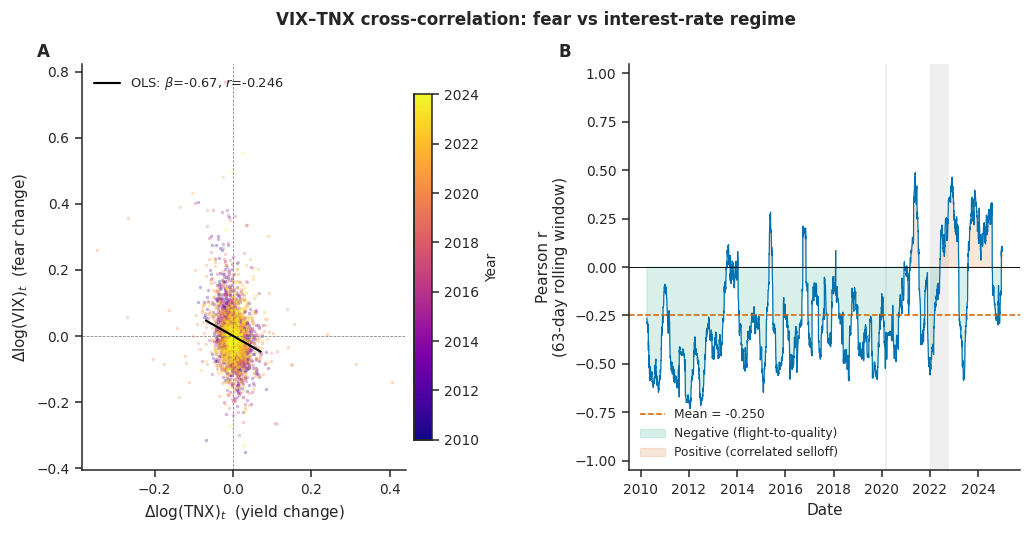

VIX–TNX cross-correlation (n = 3,772 days):
  Pearson r(Δlog VIX, Δlog TNX) = -0.2461  (p = 3.6e-53)
  OLS slope β                   = -0.6738
  Rolling mean correlation       = -0.2501
  % of 63-day windows negative  = 81.6%


In [23]:
# Cell T.5: Figure T.4 — VIX–TNX cross-correlation
import matplotlib.dates as mdates
from scipy import stats as scipy_stats

shared_vt = vix_ret.index.intersection(tnx_change.index)
vr_vt = vix_ret.loc[shared_vt]
tr_vt = tnx_change.loc[shared_vt]
years_vt = vr_vt.index.year

slope_vt, intercept_vt, rval_vt, pval_vt, _ = scipy_stats.linregress(
    tr_vt.values, vr_vt.values
)
roll_corr_vt = tr_vt.rolling(63).corr(vr_vt)

fig, (axS, axR) = plt.subplots(1, 2, figsize=(11, 4.8),
                                gridspec_kw={"wspace": 0.40})
fig.suptitle("VIX–TNX cross-correlation: fear vs interest-rate regime",
             fontsize=11, fontweight="bold")

# (A) scatter coloured by year
cmap_vt = plt.get_cmap("plasma")
year_vals_vt = years_vt.unique()
norm_vt = plt.Normalize(year_vals_vt.min(), year_vals_vt.max())

for yr in year_vals_vt:
    mask = (years_vt == yr)
    axS.scatter(tr_vt[mask], vr_vt[mask],
                s=5, alpha=0.30, color=cmap_vt(norm_vt(yr)),
                rasterized=True, linewidths=0)

x_fit = np.linspace(tr_vt.quantile(0.01), tr_vt.quantile(0.99), 100)
axS.plot(x_fit, intercept_vt + slope_vt * x_fit, color="k", lw=1.4, zorder=5,
         label=fr"OLS: $\beta$={slope_vt:.2f}, $r$={rval_vt:.3f}")
axS.axhline(0, color="grey", lw=0.5, ls="--")
axS.axvline(0, color="grey", lw=0.5, ls="--")
axS.set_xlabel(r"$\Delta\log(\mathrm{TNX})_t$  (yield change)", fontsize=10)
axS.set_ylabel(r"$\Delta\log(\mathrm{VIX})_t$  (fear change)", fontsize=10)
axS.legend(fontsize=8.5, loc="upper left", framealpha=0.9)
axS.text(-0.14, 1.05, "A", transform=axS.transAxes,
         fontsize=11, fontweight="bold", va="top")

sm_vt = plt.cm.ScalarMappable(cmap=cmap_vt, norm=norm_vt)
sm_vt.set_array([])
cbar_vt = fig.colorbar(sm_vt, ax=axS, pad=0.02, shrink=0.85)
cbar_vt.set_label("Year", fontsize=9)

# (B) rolling 63-day correlation
axR.plot(roll_corr_vt.index, roll_corr_vt.values, lw=0.8, color=OKABE_ITO[4])
axR.axhline(0, color="k", lw=0.6, ls="-")
axR.axhline(roll_corr_vt.mean(), color=OKABE_ITO[5], lw=1.0, ls="--",
            label=f"Mean = {roll_corr_vt.mean():.3f}")
axR.fill_between(roll_corr_vt.index, roll_corr_vt.values, 0,
                 where=(roll_corr_vt.values < 0), alpha=0.15,
                 color=OKABE_ITO[2], label="Negative (flight-to-quality)")
axR.fill_between(roll_corr_vt.index, roll_corr_vt.values, 0,
                 where=(roll_corr_vt.values >= 0), alpha=0.15,
                 color=OKABE_ITO[5], label="Positive (correlated selloff)")
for start_str, end_str, _ in REGIMES:
    axR.axvspan(pd.Timestamp(start_str), pd.Timestamp(end_str),
                alpha=0.12, color="0.5", linewidth=0)
axR.set_ylim(-1.05, 1.05)
axR.set_ylabel("Pearson r\n(63-day rolling window)", fontsize=10)
axR.set_xlabel("Date", fontsize=10)
axR.legend(fontsize=8, loc="lower left", framealpha=0.9)
axR.xaxis.set_major_locator(mdates.YearLocator(2))
axR.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axR.text(-0.18, 1.05, "B", transform=axR.transAxes,
         fontsize=11, fontweight="bold", va="top")

sns.despine(fig)
fig.tight_layout()
save_fig(fig, "eda_t4_vix_tnx_crosscorr")
plt.show()

print(f"VIX–TNX cross-correlation (n = {len(vr_vt):,} days):")
print(f"  Pearson r(Δlog VIX, Δlog TNX) = {rval_vt:+.4f}  (p = {pval_vt:.1e})")
print(f"  OLS slope β                   = {slope_vt:+.4f}")
print(f"  Rolling mean correlation       = {roll_corr_vt.mean():+.4f}")
pct_neg = (roll_corr_vt.dropna() < 0).mean()
print(f"  % of 63-day windows negative  = {pct_neg:.1%}")